In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Numerical operations
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split


from sklearn.preprocessing import StandardScaler


from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers



In [ ]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Celestial/neural-network/dataset/customer_churn_dataset.csv')

# Display first 5 rows
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [ ]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check churn distribution
print("\nChurn Distribution:")
print(df['Churn'].value_counts())

Dataset Shape: (440833, 12)

Missing Values:
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

Churn Distribution:
Churn
1.0    249999
0.0    190833
Name: count, dtype: int64


Handle Missing Values

In [ ]:

num_cols = ['Age', 'Tenure', 'Usage Frequency',
            'Support Calls', 'Payment Delay',
            'Total Spend', 'Last Interaction']

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

Convert Categorical Data

In [ ]:
# Convert categorical columns into numbers
df = pd.get_dummies(df,
                    columns=['Gender',
                             'Subscription Type',
                             'Contract Length'],
                    drop_first=True)

df.head()


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,2.0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,1.0,False,False,True,False,False
1,3.0,65.0,49.0,1.0,10.0,8.0,557.0,6.0,1.0,False,False,False,True,False
2,4.0,55.0,14.0,4.0,6.0,18.0,185.0,3.0,1.0,False,False,False,False,True
3,5.0,58.0,38.0,21.0,7.0,7.0,396.0,29.0,1.0,True,False,True,True,False
4,6.0,23.0,32.0,20.0,5.0,8.0,617.0,20.0,1.0,True,False,False,True,False


In [ ]:
# Remove CustomerID
df.drop('CustomerID', axis=1, inplace=True)

# Remove rows where target is missing
df.dropna(subset=['Churn'], inplace=True)

Define Features and Target

Train Test Split

In [ ]:
# Check missing values
print(df.isnull().sum())

Age                           0
Tenure                        0
Usage Frequency               0
Support Calls                 0
Payment Delay                 0
Total Spend                   0
Last Interaction              0
Churn                         0
Gender_Male                   0
Subscription Type_Premium     0
Subscription Type_Standard    0
Contract Length_Monthly       0
Contract Length_Quarterly     0
dtype: int64


In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

Convert to Float

In [ ]:
X = X.astype('float32')
y = y.astype('float32')

In [ ]:
df.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,1.0,False,False,True,False,False
1,65.0,49.0,1.0,10.0,8.0,557.0,6.0,1.0,False,False,False,True,False
2,55.0,14.0,4.0,6.0,18.0,185.0,3.0,1.0,False,False,False,False,True
3,58.0,38.0,21.0,7.0,7.0,396.0,29.0,1.0,True,False,True,True,False
4,23.0,32.0,20.0,5.0,8.0,617.0,20.0,1.0,True,False,False,True,False


In [ ]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (352665, 12)
Testing data: (88167, 12)


Feature Scaling

In [ ]:
# Scale data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
print(np.isnan(X_train).sum())
print(np.isnan(X_test).sum())

print(np.isinf(X_train).sum())
print(np.isinf(X_test).sum())

0
0
0
0


Build Neural Network

Input (input_dim)
   
   ↓

Dense (32 neurons, ReLU)
   
   ↓

Dropout (20%)
   
   ↓

Dense (16 neurons, ReLU)
   
   ↓

Dropout (20%)
   
   ↓

Dense (1 neuron, Sigmoid)
   
   ↓
   
Output (Probability 0 to 1)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

def build_model(input_dim):

    model = keras.Sequential([

        layers.Dense(
            32,
            activation='relu',
            input_shape=(input_dim,)
        ),

        layers.Dropout(0.2),

        layers.Dense(
            16,
            activation='relu'
        ),

        layers.Dropout(0.2),

        layers.Dense(
            1,
            activation='sigmoid'
        )
    ])

    model.compile(

        optimizer=keras.optimizers.Adam(
            learning_rate=0.0005
        ),

        loss='binary_crossentropy',

        metrics=['accuracy']
    )

    return model

Train Model

In [ ]:
model = build_model(X_train.shape[1])
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=1024,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7899 - loss: 0.4379 - val_accuracy: 0.9114 - val_loss: 0.2313
Epoch 2/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9086 - loss: 0.2288 - val_accuracy: 0.9344 - val_loss: 0.1689
Epoch 3/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9309 - loss: 0.1805 - val_accuracy: 0.9495 - val_loss: 0.1353
Epoch 4/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9445 - loss: 0.1501 - val_accuracy: 0.9613 - val_loss: 0.1092
Epoch 5/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9571 - loss: 0.1224 - val_accuracy: 0.9713 - val_loss: 0.0855
Epoch 6/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9668 - loss: 0.0987 - val_accuracy: 0.9771 - val_loss: 0.0689
Epoch 7/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9733 - loss: 0.0828 - val_accuracy: 0.9815 - val_loss: 0.0580
Epoch 8/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9776 - loss: 0.0715 - val_accuracy: 0

### Visualize Training History

Let's plot the training loss and validation loss over epochs to see how the model learned.

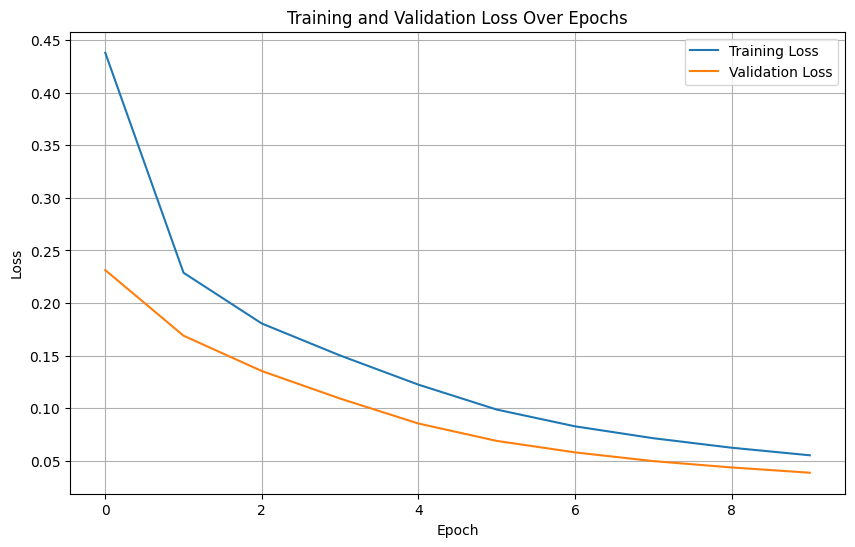

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Evaluate Model

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

2756/2756 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9886 - loss: 0.0383
Test Loss : 0.03825102001428604
Test Accuracy : 0.9886011481285095


Predictions

In [ ]:
y_pred_prob = model.predict(X_test)

2756/2756 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


Convert Probability to Class

In [ ]:
y_pred = (y_pred_prob > 0.5).astype(int)

Accuracy Score

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", round(acc * 100, 2), "%")

Accuracy: 98.86 %


Confusion Matrix

In [ ]:
df.describe()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


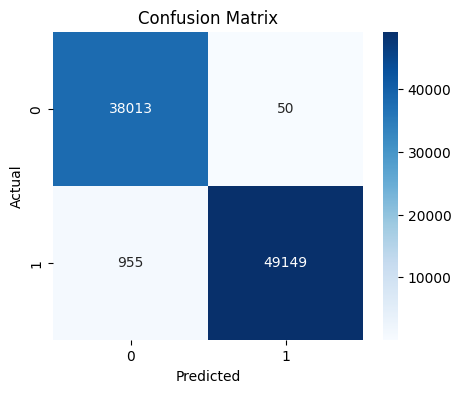

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99     38063
         1.0       1.00      0.98      0.99     50104

    accuracy                           0.99     88167
   macro avg       0.99      0.99      0.99     88167
weighted avg       0.99      0.99      0.99     88167



### Sample Prediction and Accuracy

In [ ]:
# Evaluate model
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)
print("Test Accuracy :", round(test_accuracy * 100, 2), "%")
print("Test Loss     :", round(test_loss, 4))

sample = X_test[0].reshape(1, -1)

# Predict probability

prediction = model.predict(sample)

print("\nPrediction Probability:", prediction[0][0])

# Convert to class

predicted_class = (prediction > 0.5).astype(int)

print("Predicted Class:", predicted_class[0][0])

# Actual label

print("Actual Class   :", y_test.iloc[0])

Test Accuracy : 98.86 %
Test Loss     : 0.0383
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

Prediction Probability: 1.0
Predicted Class: 1
Actual Class   : 1.0


In [ ]:
# Take one customer record from test data

sample = X_test[0].reshape(1, -1)

# Predict churn probability

prediction = model.predict(sample)

# Convert probability into class

predicted_class = 1 if prediction[0][0] > 0.5 else 0

# Actual value

actual_class = y_test.iloc[0]

# Print results

print("Prediction Probability :", round(prediction[0][0], 4))

if predicted_class == 1:
    print("Predicted Result       : Customer Will Churn")
else:
    print("Predicted Result       : Customer Will Stay")

print("Actual Result          :", actual_class)

# Check correctness

if predicted_class == actual_class:
    print("Prediction Status      : Correct Prediction")
else:
    print("Prediction Status      : Wrong Prediction")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Prediction Probability : 1.0
Predicted Result       : Customer Will Churn
Actual Result          : 1.0
Prediction Status      : Correct Prediction


In [ ]:
# Manual customer input

sample_data = [[
    35,
    12,
    15,
    2,
    1,
    5000,
    10,

    1,

    0,
    1,

    1,
    0
]]

# Scale input

sample_scaled = scaler.transform(sample_data)

# Predict

prediction = model.predict(sample_scaled)

probability = prediction[0][0]

# Print probability

print("Prediction Probability :", round(probability, 4))

# Classification

if probability > 0.5:
    print("Predicted Result : Customer Will Churn")
else:
    print("Predicted Result : Customer Will Stay")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Prediction Probability : 1.0
Predicted Result : Customer Will Churn


In [ ]:
df.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,1.0,False,False,True,False,False
1,65.0,49.0,1.0,10.0,8.0,557.0,6.0,1.0,False,False,False,True,False
2,55.0,14.0,4.0,6.0,18.0,185.0,3.0,1.0,False,False,False,False,True
3,58.0,38.0,21.0,7.0,7.0,396.0,29.0,1.0,True,False,True,True,False
4,23.0,32.0,20.0,5.0,8.0,617.0,20.0,1.0,True,False,False,True,False


In [ ]:
df.tail()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
440828,42.0,54.0,15.0,1.0,3.0,716.38,8.0,0.0,True,True,False,False,False
440829,25.0,8.0,13.0,1.0,20.0,745.38,2.0,0.0,False,True,False,False,False
440830,26.0,35.0,27.0,1.0,5.0,977.31,9.0,0.0,True,False,True,False,True
440831,28.0,55.0,14.0,2.0,0.0,602.55,2.0,0.0,True,False,True,False,True
440832,31.0,48.0,20.0,1.0,14.0,567.77,21.0,0.0,True,True,False,False,True


In [ ]:
sample_data = [[
    30.0, 39.0, 14.0,5.0,18.0,932.0,17.0,0,0,1,0,0
]]

# Scale input

sample_scaled = scaler.transform(sample_data)

# Predict

prediction = model.predict(sample_scaled)

probability = prediction[0][0]

# Print probability

print("Prediction Probability :", round(probability, 4))





1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Prediction Probability : 1.0


In [ ]:
sample_data=[[
    55.0,14.0,4.0,6.0,18.0,185.0,3.0,0,0,0,0,1
]]
# Scale input

sample_scaled = scaler.transform(sample_data)

# Predict

prediction = model.predict(sample_scaled)

probability = prediction[0][0]

# Print probability

print("Prediction Probability :", round(probability, 4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Prediction Probability : 1.0


In [ ]:
sample3=[[
31.0,	48.0,	20.0,	1.0,	14.0,	567.77,	21.0,	1,1	,0,0,1
]]
# Scale input
sample_scaled = scaler.transform(sample3)
# Predict
prediction = model.predict(sample_scaled)
probability = prediction[0][0]
# Print probability
print("Prediction Probability :", round(probability, 4))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Prediction Probability : 0.0096
